In [7]:
## modify us
## inputs
select_id_file = "BST_output/E14.5_embryo_dox_E10.5_CA/01.fastq2BcUmi/out.select_id"
parsed_barcodes_file = "BST_output/E14.5_embryo_dox_E10.5_CA/01.fastq2BcUmi/out.bc_umi_read.tsv.id"
dar_reads = "cutadapt/E14.5_embryo_dox_E10.5_CA_R2.trimmed.fastq.gz"
sample = "E14.5_embryo_dox_E10.5"
## outputs
features_file = "BST_output/E14.5_embryo_dox_E10.5_CA/02.Umi2Gene/features.tsv"
umi2gene_file = "BST_output/E14.5_embryo_dox_E10.5_CA/02.Umi2Gene/out.umi_gene.tsv"
output_dir = "BST_output/E14.5_embryo_dox_E10.5_CA/02.Umi2Gene/"

In [8]:
## other parameters
read_cutoff_whitelist = 3
read_cutoff_denoise = 1
distance_relative_threshold = 0.05

In [9]:
import os
import gzip
import pandas as pd
import numpy as np
import warnings
from Bio import SeqIO
from mosaiclineage import larry

import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')

In [10]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

## Load and extract DARLIN, spatial bc, and UMI 

In [11]:
# load DARLIN sequence
seq_list = []
with gzip.open(dar_reads, "rt") as handle:
    for record in SeqIO.parse(handle, "fastq"):
        seq_list.append(str(record.seq))

In [12]:
# filter by valid barcodes
select_id = [int(i.rstrip()) for i in open(select_id_file).readlines()]
N_total_reads = len(seq_list)
N_valid_barcodes = len(select_id)
ratio = N_valid_barcodes / N_total_reads * 100
messages = f"Total reads:\t\t{N_total_reads}\nValid barcodes:\t\t{N_valid_barcodes}({ratio:.2f}%)"
print(messages)
seq_list = [seq_list[i] for i in select_id]

Total reads:		1127783
Valid barcodes:		1010238(89.58%)


In [13]:
# load spatial barcodes & umi
bc_list, umi_list, read_id_list = [], [], []
with open(parsed_barcodes_file, 'r') as fi:
    for line in fi:
        items = line.rstrip().split('\t')
        for i in items[2:]:
            read_id_list.append(int(i))
            bc_list.append(items[0])
            umi_list.append(items[1])

In [14]:
# load into dataframe
df_seq = pd.DataFrame(
    {
        "cell_bc": bc_list,
        "umi": umi_list,
        "read_id": read_id_list
    }
)

df_tmp = pd.DataFrame(
    {
        "Seq": seq_list,
        "read_id": select_id
    }
)

## merge DARLIN [read2] and spatial bc+umi [read1]
df_seq = pd.merge(df_seq, df_tmp, on='read_id', how='outer')
assert df_tmp.shape[0] == df_seq.shape[0], "The barcode and darlin sequence are not matched!"
del df_tmp
## rename columns
df_seq["clone_id"] = df_seq["Seq"]
df_seq = df_seq.drop(["read_id", "Seq"], axis=1)

## Count reads by spatial bc + umi + DARLIN sequence

In [15]:
df_seq["unique_id"] = (
    df_seq["cell_bc"] + "_" + df_seq["umi"] + "_" + df_seq["clone_id"]
)
df_tmp = (
    df_seq.groupby("unique_id").agg(
        read=("unique_id", "count")).reset_index()
)
df_seq = df_seq.filter(
    [
        "cell_bc",
        "umi",
        "clone_id",
        "unique_id",
    ]
).merge(df_tmp, on="unique_id").drop(["unique_id"], axis=1).drop_duplicates()

del df_tmp

In [16]:
## remove columns
df_seq.columns = ['cell_bc', 'umi', 'clone_id', 'read']
df_seq['library'] = sample
df_seq["cell_id"] = df_seq["library"] + "_" + df_seq["cell_bc"]
df_seq["umi_id"] = df_seq["cell_bc"] + "_" + df_seq["umi"]
df_seq['raw_seq'] = df_seq['clone_id']

## QC metrics

Identified 3201 putative cell_id


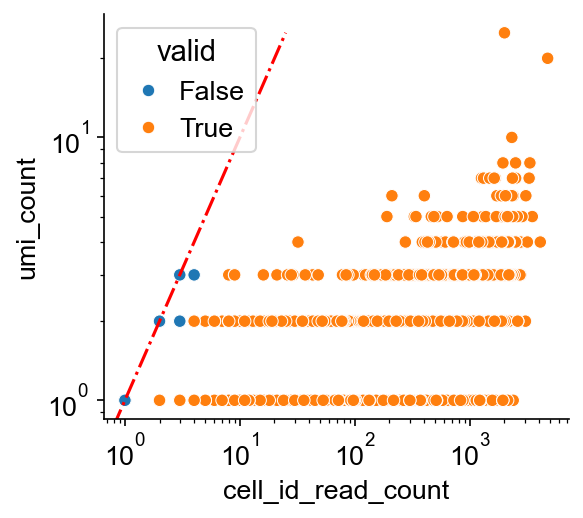

In [17]:
df_valid_cells = larry.extract_putative_valid_cell_id(df_seq, signal_threshold=1.5, cell_key="cell_id")

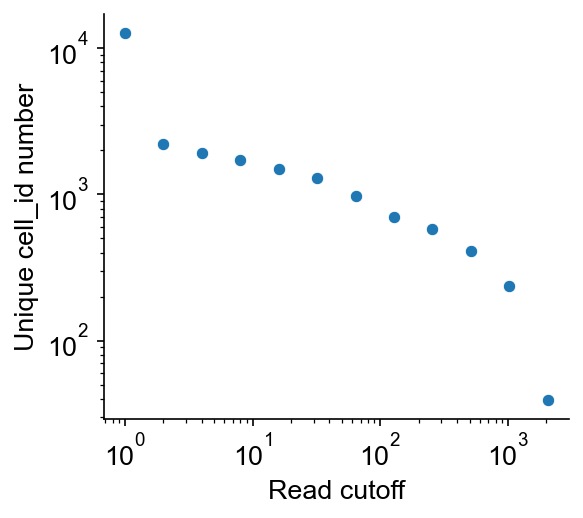

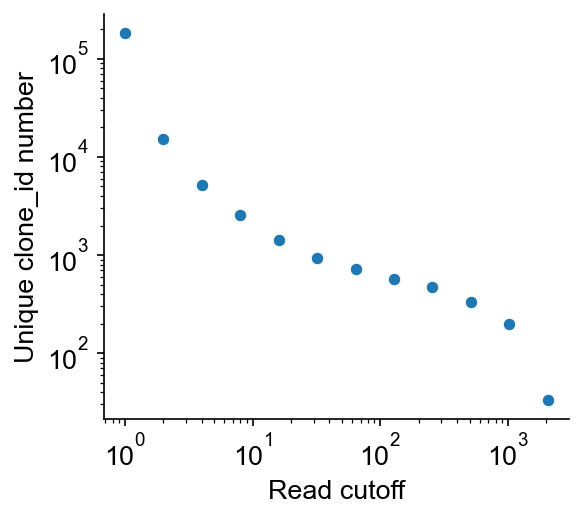

In [18]:
df_unique = larry.QC_unique_cells(df_seq, target_keys=['cell_id','clone_id'])

In [19]:
larry.print_statistics(df_seq)

library number: 1
cell_id number: 12747
clone_id number: 184590
umi_id number: 14879
total reads: 1010K


## Denoise DARLIN sequence

Text(0.5, 1.0, 'Raw CARLIN length dist (UMI): 265248 count')

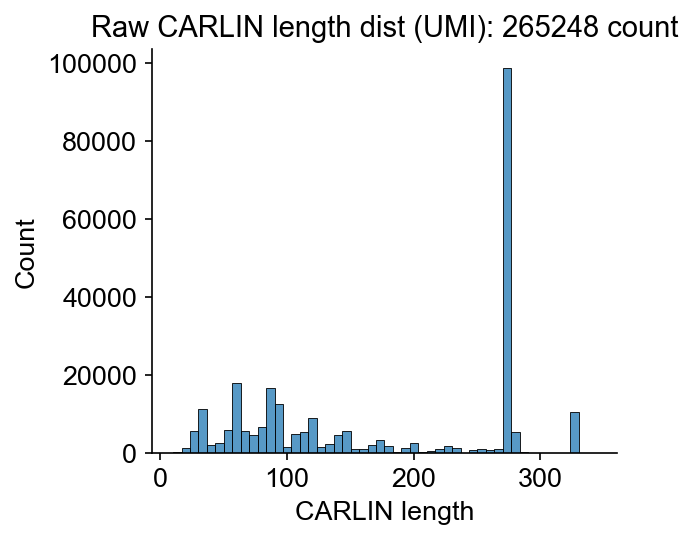

In [20]:
df_filter_reads = df_seq.copy()
df_filter_reads['bc_length']=df_filter_reads['clone_id'].apply(lambda x: len(x))
unique_bc_length=df_filter_reads['bc_length'] #list(set(df_filter_reads['bc_length']))
ax=sns.histplot(unique_bc_length,bins=50)
ax.set_xlabel('CARLIN length')
ax.set_title(f'Raw CARLIN length dist (UMI): {len(unique_bc_length)} count')

### Generate whitelist

Using a larger read_cutoff (read_cutoff_whitelist)

In [21]:
df_list=[]
unique_seq_length=list(set(df_filter_reads['bc_length']))
for target_length in sorted(unique_seq_length):
    df_tmp=df_filter_reads[df_filter_reads['bc_length']==target_length]#.groupby(['cell_bc','clone_id']).agg({'read':'sum'})
    df_HQ=larry.denoise_clonal_data(df_tmp,
        target_key="clone_id",
        denoise_method="Hamming",  # UMI_tools, 'Hamming'
        distance_threshold=np.max([1,int(target_length*distance_relative_threshold)]), #np.max([1,int(target_length*distance_relative_threshold)]),      
        read_cutoff=read_cutoff_whitelist,
        whiteList=None,
        plot_report=False,
        progress_bar=False)
    df_list.append(df_HQ)
df_denoise_bc_1=pd.concat(df_list)

In [22]:
larry.print_statistics(df_denoise_bc_1)

library number: 1
cell_id number: 2002
clone_id number: 1211
total reads: 745K


In [23]:
## spatial_bc+umi -> DARLIN sequence: one to many; expected: one to one
df_denoise_bc_1['total_reads'] = df_denoise_bc_1.groupby(['cell_bc', 'umi'])['read'].transform("sum")
df_denoise_bc_1['prop'] = df_denoise_bc_1['read'] / df_denoise_bc_1['total_reads']
## spatial_bc+umi -> DARLIN sequence: one to one; [note: the one with 60% supported reads]
## correct the sequencing error
df_denoise_bc_2 = df_denoise_bc_1[df_denoise_bc_1['prop'] > 0.6].reset_index(drop=True).copy()

In [24]:
larry.print_statistics(df_denoise_bc_2)

library number: 1
cell_id number: 2000
clone_id number: 878
total reads: 739K


In [25]:
# tmp = df_denoise_bc_1.sort_values(['cell_bc', 'umi', 'read'], ascending=[True, True, False]).groupby('cell_bc')
# tmp.apply(lambda x: x).to_csv('df_denoise_bc_1.csv')

### Denoise with whitelist

Using a lower read_cutoff (read_cutoff_denoise)

In [26]:
whitelist = df_denoise_bc_2['clone_id'].unique()
whitelist = list(whitelist)
df_wl = pd.DataFrame({
    "seq": whitelist,
    "len": [len(i) for i in whitelist]
})

In [27]:
df_list=[]
unique_seq_length=list(set(df_filter_reads['bc_length']))
for target_length in sorted(unique_seq_length):
    df_tmp=df_filter_reads[df_filter_reads['bc_length']==target_length]#.groupby(['cell_bc','clone_id']).agg({'read':'sum'})
    whitelist = df_wl[df_wl['len'] == target_length]['seq'].tolist()
    df_HQ=larry.denoise_clonal_data(df_tmp,
        target_key="clone_id",
        denoise_method="Hamming",  # UMI_tools, 'Hamming'
        distance_threshold=np.max([1,int(target_length*distance_relative_threshold)]), #np.max([1,int(target_length*distance_relative_threshold)]),      
        read_cutoff=read_cutoff_denoise,
        whiteList=whitelist,
        plot_report=False,
        progress_bar=False)
    df_list.append(df_HQ)
df_denoise_bc_1=pd.concat(df_list)

In [28]:
larry.print_statistics(df_denoise_bc_1)

library number: 1
cell_id number: 8415
clone_id number: 878
total reads: 951K


In [29]:
## spatial_bc+umi -> darline sequence: one to many; expected: one to one
df_denoise_bc_1['total_reads'] = df_denoise_bc_1.groupby(['cell_bc', 'umi'])['read'].transform("sum")
df_denoise_bc_1['prop'] = df_denoise_bc_1['read'] / df_denoise_bc_1['total_reads']
## spatial_bc+umi -> darline sequence: one to one; [note: the one with 60% supported reads]
df_denoise_bc_2 = df_denoise_bc_1[df_denoise_bc_1['prop'] > 0.6].reset_index(drop=True).copy()

In [30]:
larry.print_statistics(df_denoise_bc_2)

library number: 1
cell_id number: 7841
clone_id number: 875
total reads: 910K


## Save results for spatial

1. `umi_gene.tsv`: UMI to DARLIN
2. `features.tsv`: DARLIN species (clone id)

In [31]:
df_denoise_bc_2 = df_denoise_bc_2.filter(['cell_bc', 'umi', 'clone_id', 'read'])
df_denoise_bc_2.to_csv(umi2gene_file, sep='\t', header=False, index=False)

df_features = pd.DataFrame({
    "id": df_denoise_bc_2['clone_id'].drop_duplicates(),
    "name": df_denoise_bc_2['clone_id'].drop_duplicates()
})
df_features['type'] = "Lineage Barcode"

df_features.to_csv(features_file, sep='\t', header=False, index=False)